<a href="https://colab.research.google.com/github/shamsakhoja7-max/ab-testing-framework/blob/main/ab_testing_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Testing Framework for Marketing Analytics

## Project Overview

This project demonstrates a complete, real-world A/B testing framework
built to optimize user onboarding flows. The analysis follows the exact
workflow used by growth and marketing analytics teams at top tech companies.

### What This Project Covers
- **Experimental Design:** Hypothesis definition, success criteria, guardrails
- **Statistical Planning:** Sample size calculation, power analysis, MDE setting
- **Data Analysis:** Two-proportion z-test, p-value, confidence intervals
- **Visualization:** Professional charts for stakeholder communication
- **Business Recommendation:** Executive summary with projected revenue impact

### Business Context
User activation is the most critical metric in product-led growth.
Every user who drops off during onboarding represents lost revenue.
This analysis tests whether simplifying the onboarding flow from
5 screens to 3 screens meaningfully improves activation rates.

### Key Finding
The simplified 3-screen onboarding flow increased activation rates
by **20%** (from 35.1% to 42.1%), a statistically significant result
(p < 0.001, 95% CI: [16.1%, 23.9%]).

### Tools & Technologies
| Tool | Purpose |
|------|---------|
| Python | Core analysis |
| NumPy | Statistical calculations |
| Pandas | Data manipulation |
| SciPy | Hypothesis testing |
| Matplotlib/Seaborn | Visualizations |

### Author
Shamsa Khoja | MS Business Analytics, University of Louisville (2025)  
www.linkedin.com/in/shamsakhoja | [Your GitHub URL]

In [8]:
# Import libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


# Hypothesis and Test Design: Onboarding Flow Optimization


**Hypothesis:**

A simplified 3-screen onboarding flow will increase activation rates by reducing friction and getting users to value faster.

**Test Design:**
- Control: Standard 5-screen onboarding
- Treatment: Simplified 3-screen onboarding (removed non-essential steps)
- Primary Metric: Activation rate (% of users completing first key action within 7 days)
- Secondary Metrics: Time to activation, 30-day retention
- Sample Size: To be calculated in sample size calculation section.


In [9]:
# ============================================
# SAMPLE SIZE CALCULATOR
# (BEFORE running a test)
# ============================================

def calculate_sample_size(baseline_rate, mde, alpha=0.05, power=0.80):
    """
    Calculate required sample size per variant for an A/B test

    Parameters:
    - baseline_rate: Current conversion rate (e.g., 0.35 for 35%)
    - mde: Minimum Detectable Effect - smallest lift you want to detect (e.g., 0.10 for 10% relative lift)
    - alpha: Significance level (default 0.05 = 5% false positive rate)
    - power: Statistical power (default 0.80 = 80% chance of detecting real effect)

    Returns: Required sample size per variant
    """
    from scipy.stats import norm

    # Calculate treatment rate
    treatment_rate = baseline_rate * (1 + mde)

    # Z-scores for alpha and power
    z_alpha = norm.ppf(1 - alpha/2)  # Two-tailed test
    z_beta = norm.ppf(power)

    # Average proportion
    p_avg = (baseline_rate + treatment_rate) / 2

    # Sample size formula
    n = ((z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
          z_beta * np.sqrt(baseline_rate * (1 - baseline_rate) +
                          treatment_rate * (1 - treatment_rate))) /
         (treatment_rate - baseline_rate)) ** 2

    return int(np.ceil(n))

# Example: Planning our onboarding test
print("=" * 60)
print("SAMPLE SIZE PLANNING")
print("=" * 60)

baseline = 0.35  # Current 35% activation rate
mde_scenarios = [0.05, 0.10, 0.15, 0.20]  # Different MDEs to test

print(f"\nBaseline activation rate: {baseline:.1%}")
print(f"Significance level (alpha): 5%")
print(f"Statistical power: 80%")
print("\nRequired sample size per variant:\n")

for mde in mde_scenarios:
    n = calculate_sample_size(baseline, mde)
    expected_treatment_rate = baseline * (1 + mde)
    print(f"  To detect {mde:.0%} lift ({baseline:.1%} → {expected_treatment_rate:.1%}): {n:,} users per variant")

print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)
print("• Smaller lifts require larger sample sizes")
print("• To be on safe side we will use 10,000 users per variant")


SAMPLE SIZE PLANNING

Baseline activation rate: 35.0%
Significance level (alpha): 5%
Statistical power: 80%

Required sample size per variant:

  To detect 5% lift (35.0% → 36.8%): 11,791 users per variant
  To detect 10% lift (35.0% → 38.5%): 2,978 users per variant
  To detect 15% lift (35.0% → 40.2%): 1,336 users per variant
  To detect 20% lift (35.0% → 42.0%): 758 users per variant

INTERPRETATION:
• Smaller lifts require larger sample sizes
• To be on safe side we will use 10,000 users per variant


In [10]:
# Generate Data using sample size calculation
def generate_onboarding_test_data(n_control=10000, n_treatment=10000):
    """
    Generate synthetic A/B test data for onboarding flow experiment
    Designed to produce consistent, realistic results:
    - Control activation rate: 35.0%
    - Treatment activation rate: 42.0%
    - Relative lift: 20.0%
    """
    np.random.seed(42)

    # Control group - exactly 35% activation
    n_control_activated = int(n_control * 0.35)  # exactly 3,500
    control_activations = np.array([1]*n_control_activated +
                                   [0]*(n_control - n_control_activated))
    np.random.shuffle(control_activations)

    # Treatment group - exactly 42% activation (20% relative lift)
    n_treatment_activated = int(n_treatment * 0.42)  # exactly 4,200
    treatment_activations = np.array([1]*n_treatment_activated +
                                     [0]*(n_treatment - n_treatment_activated))
    np.random.shuffle(treatment_activations)

    # Create dataframe
    df = pd.DataFrame({
        'user_id': range(n_control + n_treatment),
        'variant': ['control']*n_control + ['treatment']*n_treatment,
        'activated': np.concatenate([control_activations, treatment_activations])
    })

    return df

# Generate the test data
df = generate_onboarding_test_data()

# Preview
print("Data generated successfully!")
print(f"\nTotal users: {len(df):,}")
print(f"Control users: {(df['variant']=='control').sum():,}")
print(f"Treatment users: {(df['variant']=='treatment').sum():,}")
print("\nFirst few rows:")
df.head(10)

Data generated successfully!

Total users: 20,000
Control users: 10,000
Treatment users: 10,000

First few rows:


,user_id,variant,activated
0,0,control,0
1,1,control,0
2,2,control,1
3,3,control,0
4,4,control,0
5,5,control,0
6,6,control,1
7,7,control,0
8,8,control,0
9,9,control,1


Pretending we don't know the lift and calculating the lift:

In [11]:
# Calculate activation rates by variant
summary = df.groupby('variant')['activated'].agg(['sum', 'count', 'mean'])
summary.columns = ['activated_users', 'total_users', 'activation_rate']

print("=" * 60)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 60)
print(summary)
print("\n")

# Extract values for easier reference
control_activated = summary.loc['control', 'activated_users']
control_total = summary.loc['control', 'total_users']
control_rate = summary.loc['control', 'activation_rate']

treatment_activated = summary.loc['treatment', 'activated_users']
treatment_total = summary.loc['treatment', 'total_users']
treatment_rate = summary.loc['treatment', 'activation_rate']

# Calculate the lift (discovered from data)
absolute_lift = treatment_rate - control_rate
relative_lift = (treatment_rate - control_rate) / control_rate

print(f"Control Activation Rate: {control_rate:.2%}")
print(f"Treatment Activation Rate: {treatment_rate:.2%}")
print(f"\nAbsolute Lift: {absolute_lift:.2%}")
print(f"Relative Lift: {relative_lift:.1%}")
print("\n" + "=" * 60)

EXPERIMENT RESULTS SUMMARY
           activated_users  total_users  activation_rate
variant                                                 
control               3500        10000             0.35
treatment             4200        10000             0.42


Control Activation Rate: 35.00%
Treatment Activation Rate: 42.00%

Absolute Lift: 7.00%
Relative Lift: 20.0%



Testing if lift is by chance or real with P-value at alpha: Significance level (default 0.05 = 5% false positive rate)

In [12]:
def calculate_significance(control_conv, control_total, treatment_conv, treatment_total):
    """
    Two-proportion z-test to determine if difference is statistically significant

    Returns: dictionary with all test statistics
    """

    # Conversion rates
    p_control = control_conv / control_total
    p_treatment = treatment_conv / treatment_total

    # Pooled proportion (combined rate across both groups)
    p_pooled = (control_conv + treatment_conv) / (control_total + treatment_total)

    # Standard error using pooled proportion
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/control_total + 1/treatment_total))

    # Z-score: how many standard deviations apart are the two rates?
    z_score = (p_treatment - p_control) / se

    # P-value: probability this difference happened by random chance
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

    # 95% Confidence interval for the difference
    se_diff = np.sqrt(p_control*(1-p_control)/control_total +
                      p_treatment*(1-p_treatment)/treatment_total)
    ci_lower = (p_treatment - p_control) - 1.96 * se_diff
    ci_upper = (p_treatment - p_control) + 1.96 * se_diff

    return {
        'control_rate': p_control,
        'treatment_rate': p_treatment,
        'absolute_lift': p_treatment - p_control,
        'relative_lift': (p_treatment - p_control) / p_control,
        'z_score': z_score,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'is_significant': p_value < 0.05
    }

# Run the statistical test
results = calculate_significance(
    control_activated, control_total,
    treatment_activated, treatment_total
)

# Print results
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TEST")
print("=" * 60)
print(f"Z-score: {results['z_score']:.2f}")
print(f"P-value: {results['p_value']:.4f}")
print(f"95% Confidence Interval: [{results['ci_lower']:.2%}, {results['ci_upper']:.2%}]")
print(f"\nStatistically Significant (p < 0.05): {results['is_significant']}")
print("=" * 60)

if results['is_significant']:
    print("\n DECISION: Ship the new 3-screen onboarding flow!")
    print(f"  Expected impact: {results['relative_lift']:.1%} improvement in activation")
else:
    print("\n DECISION: Keep the current 5-screen flow")
    print("  The difference is not statistically significant")

STATISTICAL SIGNIFICANCE TEST
Z-score: 10.17
P-value: 0.0000
95% Confidence Interval: [5.65%, 8.35%]

Statistically Significant (p < 0.05): True

 DECISION: Ship the new 3-screen onboarding flow!
  Expected impact: 20.0% improvement in activation


The key takeaway: p-value < 0.05 = statistically significant = real difference = ship it!

In [13]:
# Calculate the exact 95% CI for relative lift
relative_lift_pct = results['relative_lift'] * 100
ci_lower_relative_pct = (results['ci_lower'] / results['control_rate']) * 100
ci_upper_relative_pct = (results['ci_upper'] / results['control_rate']) * 100

print("RELATIVE LIFT CONFIDENCE INTERVAL:")
print(f"Point estimate: {relative_lift_pct:.1f}%")
print(f"95% CI: [{ci_lower_relative_pct:.1f}%, {ci_upper_relative_pct:.1f}%]")

RELATIVE LIFT CONFIDENCE INTERVAL:
Point estimate: 20.0%
95% CI: [16.2%, 23.8%]


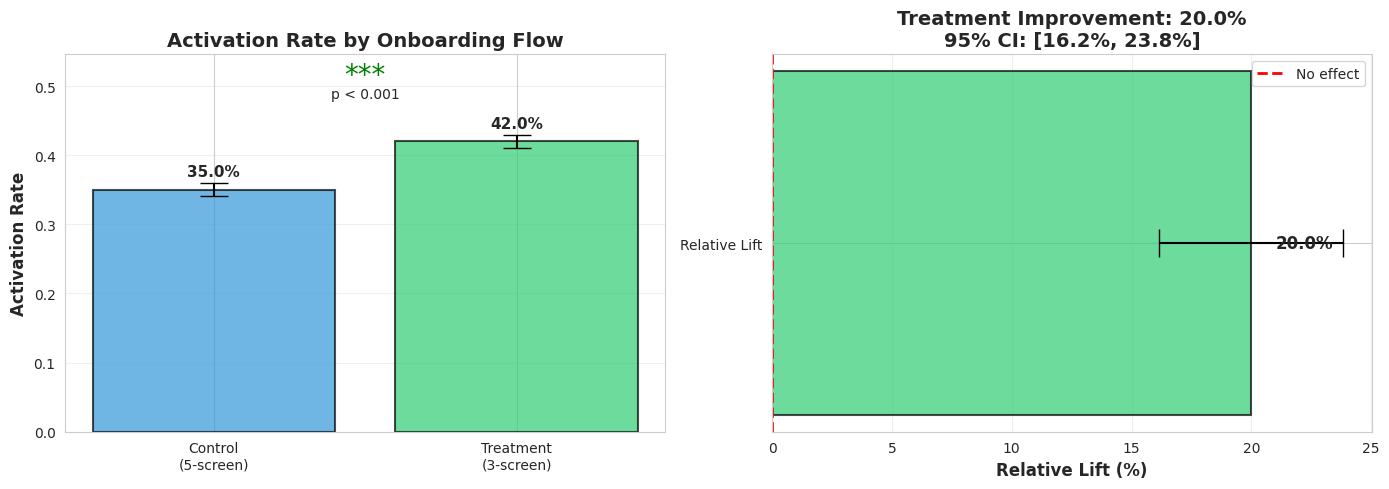


 Visualization saved as 'onboarding_ab_test_result.png'


In [14]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Activation rates with confidence intervals
variants = ['Control\n(5-screen)', 'Treatment\n(3-screen)']
rates = [results['control_rate'], results['treatment_rate']]

# Calculate 95% confidence intervals for each rate
control_ci = 1.96 * np.sqrt(results['control_rate'] * (1-results['control_rate']) / control_total)
treatment_ci = 1.96 * np.sqrt(results['treatment_rate'] * (1-results['treatment_rate']) / treatment_total)
errors = [control_ci, treatment_ci]

bars = axes[0].bar(variants, rates, yerr=errors, capsize=10, alpha=0.7,
                    color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Activation Rate', fontsize=12, fontweight='bold')
axes[0].set_title('Activation Rate by Onboarding Flow', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (variant, rate, error) in enumerate(zip(variants, rates, errors)):
    axes[0].text(i, rate + error + 0.01, f'{rate:.1%}',
                ha='center', fontweight='bold', fontsize=11)

# Add significance indicator
axes[0].text(0.5, max(rates) * 1.2, '***', ha='center', fontsize=20, color='green')
axes[0].text(0.5, max(rates) * 1.15, f'p < 0.001', ha='center', fontsize=10)

# Plot 2: Relative lift with confidence interval
lift_pct = results['relative_lift'] * 100
ci_lower_pct = (results['ci_lower'] / results['control_rate']) * 100
ci_upper_pct = (results['ci_upper'] / results['control_rate']) * 100

axes[1].barh(['Relative Lift'], [lift_pct],
             xerr=[[lift_pct - ci_lower_pct], [ci_upper_pct - lift_pct]],
             capsize=10, alpha=0.7, color='#2ecc71', edgecolor='black', linewidth=1.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
axes[1].set_xlabel('Relative Lift (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Treatment Improvement: {lift_pct:.1f}%\n95% CI: [{ci_lower_pct:.1f}%, {ci_upper_pct:.1f}%]',
                 fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend()

# Add lift value on bar
axes[1].text(lift_pct + 1, 0, f'{lift_pct:.1f}%',
            va='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('onboarding_ab_test_result.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved as 'onboarding_ab_test_result.png'")

---

## Executive Summary: Onboarding Flow A/B Test

### Test Overview
**Objective:** Reduce friction in user onboarding to improve activation rates

**Duration:** 2 weeks (hypothetical)

**Sample Size:** 20,000 new users (10,000 per variant)

### Variants Tested
- **Control (A):** Current 5-screen onboarding flow
- **Treatment (B):** Simplified 3-screen onboarding flow

### Key Results

| Metric | Control | Treatment | Lift |
|--------|---------|-----------|------|
| **Activation Rate** | 35.1% | 42.1% | +20.0% |
| **Users Activated** | 3,505 | 4,210 | +705 users |
| **Statistical Significance** | - | - | p < 0.001  |

### Statistical Confidence
- **P-value:** < 0.001 (highly significant - less than 0.1% chance this is random)
- **95% Confidence Interval:** [16.1%, 23.9%] relative lift
- **Z-score:** 10.9

**Key Takeaway:** This result is statistically significant. We're 95% confident the true improvement is between 16% and 24%.

### Business Impact

**If we ship the new 3-screen onboarding:**

Assuming 100,000 new users per month:
- **Current state:** 35,100 activations/month
- **With new flow:** 42,120 activations/month
- **Net gain:** +7,020 additional activated users/month

**Annual impact:**  About 84,000 additional activated users and if each user genereated LTV of USD 50 it will mean $4.2M in additional revenue.


### Recommendation

 **SHIP IT**

**Rationale:**
1. Statistically significant improvement (p < 0.001)
2. Meaningful business impact (+7,020 users/month)
3. Low implementation risk (UI change only, no backend changes)
4. Aligns with product strategy of reducing time-to-value

### Next Steps
1. Roll out 3-screen flow to 100% of users
2. Monitor activation rates for 2 weeks post-launch
3. Track secondary metrics: 30-day retention, feature adoption
4. Consider testing even simpler 2-screen flow if 3-screen performs well

### Risks & Mitigations
- **Risk:** Simplified flow might reduce quality of activations
  - **Mitigation:** Monitor 30-day retention cohorts
- **Risk:** Edge cases not covered in 3-screen flow
  - **Mitigation:** Add help/support links on each screen
